In [2]:
import os
import glob
import numpy as np
import pandas as pd

BASE_DIR      = os.path.dirname(os.path.abspath('__file__'))
CAT_BASE = os.path.join(BASE_DIR, 'Catherine')

FILE_LABEL_MAP = {
    'Catherine_Dry_0326_c.csv': 'Concrete',
    'Catherine_Dry_0326_b.csv':    'Brick',
    'Catherine_Dry_0326_g.csv':    'Grass',
}

PRESSURE_COLS = [f'pressure_{i:02d}' for i in range(1, 13)]

GAP_MS = 5_000  # 5 second silence gap between sessions

all_sessions = []

for csv_filename, label in FILE_LABEL_MAP.items():
    csv_path = os.path.join(CAT_BASE, csv_filename)
    running_offset = 0

    df = pd.read_csv(csv_path)
    df = df[df['corrupt'] == 0].copy()
    df = df[df['sole_id'] == 1].reset_index(drop=True)
    df['ground_type'] = label
    df['session']     = csv_filename

    df['timestamp'] = df['timestamp'] - df['timestamp'].iloc[0] + running_offset
    df['time_sec']  = df['timestamp'] / 1000.0
    df['total_pressure'] = df[PRESSURE_COLS].sum(axis=1)

    running_offset = df['timestamp'].iloc[-1] + GAP_MS

    all_sessions.append(df)
    print(f"  {label:12s} | {csv_filename:30s} | "
          f"{len(df):5d} rows | ends at {df['time_sec'].iloc[-1]:.1f}s")

raw = pd.concat(all_sessions, ignore_index=True)
print(f"\nTotal rows: {len(raw):,}")
print(raw['ground_type'].value_counts())

# ── Per-surface dataframes with continuous timestamps ─────────────
concrete_df = raw[raw['ground_type'] == 'Concrete'].reset_index(drop=True)
brick_df    = raw[raw['ground_type'] == 'Brick'].reset_index(drop=True)
grass_df    = raw[raw['ground_type'] == 'Grass'].reset_index(drop=True)

for name, df in [('concrete_df', concrete_df), ('brick_df', brick_df), ('grass_df', grass_df)]:
    print(f"{name}: {len(df):5,} rows | {df['session'].nunique()} sessions | "
          f"time range: {df['time_sec'].iloc[0]:.1f}s → {df['time_sec'].iloc[-1]:.1f}s")

  Concrete     | Catherine_Dry_0326_c.csv       |  5289 rows | ends at 89.6s
  Brick        | Catherine_Dry_0326_b.csv       |  4328 rows | ends at 73.3s
  Grass        | Catherine_Dry_0326_g.csv       |  4701 rows | ends at 75.2s

Total rows: 14,318
ground_type
Concrete    5289
Grass       4701
Brick       4328
Name: count, dtype: int64
concrete_df: 5,289 rows | 1 sessions | time range: 0.0s → 89.6s
brick_df: 4,328 rows | 1 sessions | time range: 0.0s → 73.3s
grass_df: 4,701 rows | 1 sessions | time range: 0.0s → 75.2s


## Step Segmentation

Steps are detected from the **combined heel signal** (sum of `pressure_08` and `pressure_11`) using the following pipeline:

1. **Sum the two heel sensors** into a single signal — heel contact produces a sharp, consistent spike at every heel-strike, making it a reliable segmentation anchor.
2. **Smooth with a Savitzky-Golay filter** (window=11, polynomial order=2) to remove high-frequency noise while preserving peak shape.
3. **Find peaks** using `scipy.signal.find_peaks` with `distance=50` (≥0.8 s between peaks at 62.5 Hz), `prominence=200`, and `height=500` — these thresholds isolate genuine stance peaks and reject noise.
4. **Each pair of consecutive peaks defines one step window** — the data slice from peak *k* to peak *k+1* captures one complete stance phase.

In [3]:
from scipy.signal import find_peaks, savgol_filter
import plotly.graph_objects as go

HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05', 'pressure_06', 'pressure_09']

SMOOTH_WIN    = 11
SMOOTH_POLY   = 2
BIG_PEAK_DIST = 50
BIG_PEAK_PROM = 200
BIG_PEAK_HT   = 500


def find_step_windows(df):
    """Detect stance peaks from the smoothed combined heel signal.
    Returns array of peak indices — consecutive pairs define one step window."""
    y = df[HEEL_SENSORS].sum(axis=1).to_numpy(dtype=float)
    n  = len(y)
    sw = min(SMOOTH_WIN, n - (0 if n % 2 == 1 else 1))
    if sw % 2 == 0: sw -= 1
    if sw <= SMOOTH_POLY: sw = SMOOTH_POLY + 3 + (1 if (SMOOTH_POLY + 3) % 2 == 0 else 0)
    y_sm = savgol_filter(y, window_length=sw, polyorder=min(SMOOTH_POLY, sw - 1))
    peaks, _ = find_peaks(y_sm, distance=BIG_PEAK_DIST,
                           prominence=BIG_PEAK_PROM, height=BIG_PEAK_HT)
    return peaks


surfaces = {'Concrete': concrete_df, 'Brick': brick_df, 'Grass': grass_df}

for label, df in surfaces.items():
    t         = df['time_sec'].values
    heel_sig  = df[HEEL_SENSORS].sum(axis=1).values.astype(float)
    fore_sig  = df[FOREFOOT_SENSORS].sum(axis=1).values.astype(float)
    big_peaks = find_step_windows(df)
    n_steps   = max(0, len(big_peaks) - 1)

    fig = go.Figure()

    fig.add_trace(go.Scatter(x=t, y=heel_sig, name='Heel (sum)',
                             line=dict(color='#E15759', width=1.5)))
    fig.add_trace(go.Scatter(x=t, y=fore_sig, name='Forefoot (sum)',
                             line=dict(color='#4C72B0', width=1.5)))

    # light shading between windows
    for k in range(n_steps):
        p1, p2 = big_peaks[k], big_peaks[k + 1]
        fig.add_vrect(x0=float(t[p1]), x1=float(t[p2]),
                      fillcolor='mediumseagreen', opacity=0.10, line_width=0,
                      annotation_text=str(k + 1), annotation_position='top left',
                      annotation=dict(font_size=8))

    # solid vertical lines at every peak boundary
    for k, p in enumerate(big_peaks):
        fig.add_vline(x=float(t[p]), line=dict(color='seagreen', width=1.5, dash='dash'))

    fig.update_layout(title=f'{label} — Heel vs Forefoot pressure  ({n_steps} steps)',
                      xaxis_title='Time (s)', yaxis_title='Pressure (ADC)',
                      template='plotly_white', height=350,
                      legend=dict(orientation='h', x=0, y=-0.2))
    fig.show()

    print(f"{label}: {n_steps} steps detected")
    
#concrete: 27, 58, 90, 120, 
#brick: 30, 61, 83,
#grass: 21, 43

Concrete: 88 steps detected


Brick: 73 steps detected


Grass: 73 steps detected


In [4]:
from scipy.stats import skew, kurtosis

IMU_COLS = ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'magn_x', 'magn_y', 'magn_z']

records = []

for label, df in surfaces.items():
    big_peaks = find_step_windows(df)

    for k in range(len(big_peaks) - 1):
        p1, p2   = big_peaks[k], big_peaks[k + 1]
        window   = df.iloc[p1:p2]
        n        = len(window)

        row = {
            'ground_type':          label,
            'step':                 k + 1,
            'step_duration':        n,
            'total_pressure_mean':  window['total_pressure'].mean(),
            'stance_auc':           np.trapezoid(window['total_pressure'].values,
                                                 window['time_sec'].values),
        }

        for col in PRESSURE_COLS + IMU_COLS:
            x = window[col].values.astype(float)
            row[f'{col}_mean']     = x.mean()
            row[f'{col}_std']      = x.std()
            row[f'{col}_max']      = x.max()
            row[f'{col}_min']      = x.min()
            row[f'{col}_skew']     = skew(x)
            row[f'{col}_kurtosis'] = kurtosis(x)

        records.append(row)

steps_df = pd.DataFrame(records)
print(steps_df.shape)
steps_df.head()


(234, 131)


,ground_type,step,step_duration,total_pressure_mean,stance_auc,pressure_01_mean,pressure_01_std,pressure_01_max,pressure_01_min,pressure_01_skew,...,magn_y_max,magn_y_min,magn_y_skew,magn_y_kurtosis,magn_z_mean,magn_z_std,magn_z_max,magn_z_min,magn_z_skew,magn_z_kurtosis
0,Concrete,1,55,3060.272727,2797.040,285.509091,145.448882,558.0,143.0,0.865956,...,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
1,Concrete,2,60,3176.900000,3205.000,288.666667,139.290185,550.0,137.0,0.831063,...,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
2,Concrete,3,58,3171.568966,3040.520,308.344828,157.203202,560.0,137.0,0.424562,...,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
3,Concrete,4,58,3253.465517,3167.064,285.948276,136.315863,551.0,138.0,0.812882,...,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
4,Concrete,5,59,3257.779661,3158.000,316.813559,155.580866,558.0,144.0,0.317513,...,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN


In [5]:
# ── Remove transition steps ───────────────────────────────────────
transition_steps = {
    'Concrete': [27, 58, 90, 120],
    'Brick':    [30, 61, 83],
    'Grass':    [21, 43],
}

before = len(steps_df)

for ground_type, step_nums in transition_steps.items():
    mask = (steps_df['ground_type'] == ground_type) & (steps_df['step'].isin(step_nums))
    steps_df = steps_df[~mask]

steps_df = steps_df.reset_index(drop=True)

print(f"Removed {before - len(steps_df)} transition steps")
print(f"Remaining: {len(steps_df)} steps")
print(steps_df['ground_type'].value_counts())

Removed 6 transition steps
Remaining: 228 steps
ground_type
Concrete    86
Brick       71
Grass       71
Name: count, dtype: int64


## Loading Rate

Loading rate measures how quickly pressure builds up at heel-strike — the steepness of the initial loading ramp. It is computed per heel sensor and then averaged across both sensors.

**Method** (identical to `load_rate_fixed_v7`):

1. **Contact point** (`c`) — the sample with the **minimum** heel sensor value in the step window `[p1, p2]`. This is the quietest point just before the foot makes firm contact.
2. **Hill peak** (`h`) — the **first local maximum** of the raw sensor signal within `HILL_WINDOW = 10` samples (~160 ms at 62.5 Hz) after contact. If no local peak is found, the sample with the highest value in that range is used.
3. **Loading rate** = `(pressure_h − pressure_c) / (time_h − time_c)` — pressure rise per second (ADC/s).
4. Steps are only kept if **both** heel sensors produced a valid loading event (`dp ≥ 5` ADC, `dt > 0`), and the per-sensor rates are averaged.

In [6]:
from scipy.signal import find_peaks as _find_peaks

HILL_WINDOW = 10   # samples to search for heel-strike peak after contact (~160 ms at 62.5 Hz)
MIN_DP      = 5    # min pressure rise to count as a valid loading event (ADC)


def compute_loading_rate(df, big_peaks):
    """
    For each step window:
      - contact (c)   = argmin of raw heel sensor signal in [p1, p2]
      - hill peak (h) = first local max within HILL_WINDOW samples of contact
      - loading_rate  = (pressure_h - pressure_c) / (time_h - time_c)  [ADC/s]
    Averaged across both heel sensors; step dropped if either sensor is invalid.
    Identical method to load_rate_fixed_v7.
    """
    t       = df['time_sec'].values
    records = []

    for i in range(len(big_peaks) - 1):
        p1, p2    = big_peaks[i], big_peaks[i + 1]
        step_lrs  = []

        for sensor in HEEL_SENSORS:
            y = df[sensor].values.astype(float)

            c_local = int(np.argmin(y[p1:p2]))
            c_idx   = p1 + c_local

            end    = min(p2, c_idx + HILL_WINDOW)
            seg    = y[c_idx:end + 1]
            lp, _  = _find_peaks(seg, prominence=1)
            h_local = lp[0] if len(lp) else int(np.argmax(seg[1:])) + 1
            h_idx   = c_idx + h_local

            dt = t[h_idx] - t[c_idx]
            dp = y[h_idx] - y[c_idx]

            if dt > 0 and dp >= MIN_DP:
                step_lrs.append(dp / dt)

        # only keep steps where both heel sensors contributed
        if len(step_lrs) == len(HEEL_SENSORS):
            records.append({'step': i + 1, 'loading_rate': float(np.mean(step_lrs))})

    return pd.DataFrame(records)


lr_dfs = []
for label, df in surfaces.items():
    big_peaks = find_step_windows(df)
    lr_df     = compute_loading_rate(df, big_peaks)
    lr_df['ground_type'] = label
    lr_dfs.append(lr_df)

lr_all   = pd.concat(lr_dfs, ignore_index=True)
steps_df = steps_df.merge(lr_all, on=['ground_type', 'step'], how='left')

print(f"Loading rate computed: {steps_df['loading_rate'].notna().sum()} / {len(steps_df)} steps")
print(steps_df[['ground_type', 'step', 'loading_rate']].head(10))

Loading rate computed: 207 / 228 steps
  ground_type  step  loading_rate
0    Concrete     1    578.125000
1    Concrete     2    328.125000
2    Concrete     3    976.562500
3    Concrete     4    479.166667
4    Concrete     5    364.583333
5    Concrete     6    781.250000
6    Concrete     7   1768.750000
7    Concrete     8    411.458333
8    Concrete     9           NaN
9    Concrete    10    640.625000


## Midstance

Midstance is the point within a step where weight has fully transferred off the heel and the forefoot takes over — the balance point between heel-dominant and forefoot-dominant loading.

**Method** (identical to `load_rate_fixed_v7`):

1. **Contact index** (`c`) — argmin of the combined heel signal in `[p1, p2]` (same as for loading rate).
2. **Crossover search** — from `c` to the end of the window, find the **first sample where forefoot sum > heel sum**. This is the midstance index.
3. **Fallback** — if no crossover is found (e.g. heel remains dominant throughout), the **window midpoint** `(c + p2) // 2` is used instead.
4. **`midstance_pressure`** — the total forefoot signal at the midstance index (sum of all 5 forefoot sensors).

`crossover_found=True` means a genuine forefoot-dominant transition was detected; `False` means the midpoint fallback was used.

In [7]:
def compute_midstance(df, big_peaks):
    """
    For each step window:
      - contact (c)         = argmin of combined heel signal in [p1, p2]
      - midstance           = first sample after c where forefoot sum > heel sum
      - fallback            = window midpoint (c + p2) // 2 if no crossover found
      - midstance_pressure  = sum of forefoot sensors at midstance index
      - time_to_midstance   = t[mid_idx] - t[c_idx], computed directly here
    Identical method to load_rate_fixed_v7.
    """
    heel_sig = df[HEEL_SENSORS].sum(axis=1).values.astype(float)
    fore_sig = df[FOREFOOT_SENSORS].sum(axis=1).values.astype(float)
    t        = df['time_sec'].values

    records = []
    for i in range(len(big_peaks) - 1):
        p1, p2  = big_peaks[i], big_peaks[i + 1]
        c_local = int(np.argmin(heel_sig[p1:p2]))
        c_idx   = p1 + c_local

        diff  = fore_sig[c_idx:p2] - heel_sig[c_idx:p2]
        cross = np.where(diff > 0)[0]

        if len(cross):
            mid_idx         = c_idx + int(cross[0])
            crossover_found = True
        else:
            mid_idx         = (c_idx + p2) // 2
            crossover_found = False

        records.append({
            'step':                i + 1,
            'midstance_pressure':  float(fore_sig[mid_idx]),
            'midstance_time_sec':  float(t[mid_idx]),
            'time_to_midstance':   float(t[mid_idx] - t[c_idx]),
            'crossover_found':     crossover_found,
        })

    return pd.DataFrame(records)


mid_dfs = []
for label, df in surfaces.items():
    big_peaks = find_step_windows(df)
    mid_df    = compute_midstance(df, big_peaks)
    mid_df['ground_type'] = label
    mid_dfs.append(mid_df)

mid_all  = pd.concat(mid_dfs, ignore_index=True)
steps_df = steps_df.merge(mid_all, on=['ground_type', 'step'], how='left')

n_cross = steps_df['crossover_found'].sum()
print(f'Midstance computed: {n_cross} / {len(steps_df)} steps used crossover, '
      f'{len(steps_df) - n_cross} used midpoint fallback')
print(steps_df[['ground_type', 'step', 'stance_auc', 'midstance_pressure',
                 'time_to_midstance', 'crossover_found']].head(10))
print(f'\nsteps_df final shape: {steps_df.shape}')


Midstance computed: 228 / 228 steps used crossover, 0 used midpoint fallback
  ground_type  step  stance_auc  midstance_pressure  time_to_midstance  \
0    Concrete     1    2797.040              1066.0                0.0   
1    Concrete     2    3205.000              1089.0                0.0   
2    Concrete     3    3040.520              2017.0                0.0   
3    Concrete     4    3167.064              2117.0                0.0   
4    Concrete     5    3158.000              1102.0                0.0   
5    Concrete     6    3149.000              1347.0                0.0   
6    Concrete     7    3335.704              1121.0                0.0   
7    Concrete     8    3172.432              1449.0                0.0   
8    Concrete     9    3322.952              1112.0                0.0   
9    Concrete    10    3153.392              2156.0                0.0   

   crossover_found  
0             True  
1             True  
2             True  
3             True  
4  

## Feature Distributions — Loading Rate & Midstance

Box plots comparing loading rate and midstance pressure across the three surfaces. Each point is one step; the box shows median and IQR.

In [8]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

SURFACE_COLORS = {'Concrete': '#4C72B0', 'Brick': '#E15759', 'Grass': '#59A14F'}

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Loading Rate by Surface', 'Midstance Pressure by Surface')
)

for surface, color in SURFACE_COLORS.items():
    sub = steps_df[steps_df['ground_type'] == surface]

    # Loading rate
    fig.add_trace(
        go.Box(
            y=sub['loading_rate'].dropna(),
            name=surface,
            marker_color=color,
            boxpoints='all',
            jitter=0.3,
            pointpos=-1.8,
            showlegend=True,
        ),
        row=1, col=1
    )

    # Midstance pressure
    fig.add_trace(
        go.Box(
            y=sub['midstance_pressure'].dropna(),
            name=surface,
            marker_color=color,
            boxpoints='all',
            jitter=0.3,
            pointpos=-1.8,
            showlegend=False,
        ),
        row=1, col=2
    )

fig.update_yaxes(title_text='Loading Rate (ADC/s)', row=1, col=1)
fig.update_yaxes(title_text='Midstance Pressure (ADC, forefoot sum)', row=1, col=2)
fig.update_layout(
    template='plotly_white',
    height=450,
    legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.15),
)
fig.show()

# Summary stats
print('Loading Rate (ADC/s):')
print(steps_df.groupby('ground_type')['loading_rate']
      .agg(['count', 'mean', 'std', 'median']).round(1).to_string())
print()
print('Midstance Pressure (ADC):')
print(steps_df.groupby('ground_type')['midstance_pressure']
      .agg(['count', 'mean', 'std', 'median']).round(1).to_string())


Loading Rate (ADC/s):
             count    mean    std  median
ground_type                              
Brick           64  1083.6  869.6   688.8
Concrete        77   676.5  497.9   479.2
Grass           66   861.4  615.6   622.4

Midstance Pressure (ADC):
             count    mean    std  median
ground_type                              
Brick           71  1245.2  339.3  1121.0
Concrete        86  1494.1  442.9  1308.0
Grass           71  1290.5  355.8  1152.0


In [9]:
steps_df.shape

(228, 136)

In [10]:
from scipy import stats

# Columns that are not features
NON_FEATURES = {'ground_type', 'step', 'contact_time_sec', 'midstance_time_sec',
                'crossover_found'}

feature_cols = [c for c in steps_df.columns if c not in NON_FEATURES]

groups = [steps_df[steps_df['ground_type'] == g] for g in ['Concrete', 'Brick', 'Grass']]

rows = []
for col in feature_cols:
    samples = [g[col].dropna().values for g in groups]
    if any(len(s) < 2 for s in samples):
        continue
    f_stat, p_val = stats.f_oneway(*samples)
    rows.append({'feature': col, 'F': f_stat, 'p': p_val})

anova_df = (pd.DataFrame(rows)
              .sort_values('p')
              .reset_index(drop=True))

anova_df['F']    = anova_df['F'].round(2)
anova_df['p']    = anova_df['p'].apply(lambda x: f'{x:.2e}')
anova_df['sig']  = anova_df['p'].apply(
    lambda x: '***' if float(x) < 0.001 else
              ('**'  if float(x) < 0.01  else
              ('*'   if float(x) < 0.05  else '')))

print(f'One-way ANOVA across Concrete / Brick / Grass  (n={len(steps_df)} steps)\n')
print(f'{"Feature":<30} {"F":>8}  {"p-value":>10}  sig')
print('-' * 56)
for _, r in anova_df.iterrows():
    print(f'{r["feature"]:<30} {r["F"]:>8}  {r["p"]:>10}  {r["sig"]}')


One-way ANOVA across Concrete / Brick / Grass  (n=228 steps)

Feature                               F     p-value  sig
--------------------------------------------------------
pressure_04_min                  260.73    2.55e-59  ***
pressure_06_min                  248.97    9.36e-58  ***
pressure_02_max                  161.77    2.88e-44  ***
pressure_09_min                  144.94    3.58e-41  ***
pressure_03_min                  143.84    5.80e-41  ***
pressure_05_max                  141.91    1.35e-40  ***
pressure_10_std                  131.28    1.65e-38  ***
step_duration                    114.23    5.74e-35  ***
pressure_02_std                   95.07    1.18e-30  ***
pressure_05_std                   92.16    5.81e-30  ***
gyro_x_std                        84.36    4.58e-28  ***
pressure_02_mean                  75.73    7.09e-26  ***
pressure_09_std                   73.93    2.10e-25  ***
pressure_10_min                   73.51    2.70e-25  ***
pressure_03_mean          

/opt/anaconda3/envs/ds3500/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: ConstantInputWarning:

Each of the input arrays is constant; the F statistic is not defined or infinite



In [11]:
steps_df.shape

(228, 136)

In [12]:
# Drop non-feature columns
feature_cols = [c for c in steps_df.columns if c not in ['ground_type', 'step', 'crossover_found']]
X = steps_df[feature_cols].apply(pd.to_numeric, errors='coerce')

# Compute correlation matrix
corr_matrix = X.corr().abs()

# Extract upper triangle only (avoid duplicates and self-correlation)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Stack and sort
corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .sort_values('correlation', ascending=False)
)

print("Top 30 most correlated feature pairs:")
print(corr_pairs.head(30).to_string(index=False))

print("\nPairs with |r| > 0.85 (highly redundant):")
print(corr_pairs[corr_pairs['correlation'] > 0.85].to_string(index=False))

Top 30 most correlated feature pairs:
           feature_1            feature_2  correlation
    pressure_11_skew pressure_11_kurtosis     0.986429
    pressure_12_skew pressure_12_kurtosis     0.975897
    pressure_08_skew pressure_08_kurtosis     0.973626
    pressure_10_skew pressure_10_kurtosis     0.970674
    pressure_01_skew pressure_01_kurtosis     0.969311
    pressure_12_mean     pressure_12_skew     0.962909
    pressure_05_skew pressure_05_kurtosis     0.953851
    pressure_06_skew pressure_06_kurtosis     0.943691
    pressure_07_skew pressure_07_kurtosis     0.942223
    pressure_02_skew pressure_02_kurtosis     0.939845
    pressure_12_mean pressure_12_kurtosis     0.933634
    pressure_04_skew pressure_04_kurtosis     0.933605
    pressure_02_skew     pressure_05_skew     0.923666
        accel_z_skew     accel_z_kurtosis     0.901783
    pressure_08_skew     pressure_11_skew     0.900527
pressure_10_kurtosis     pressure_11_skew     0.899923
    pressure_06_skew     pr

In [13]:
import numpy as np
import pandas as pd

# ── 1. Define features ────────────────────────────────────────────
drop_cols = (
    [c for c in steps_df.columns if c.endswith('_range')]
    + ['stance_auc', 'total_pressure_mean', 'time_to_midstance', 'crossover_found']
)

feature_cols_clean = [
    c for c in steps_df.columns 
    if c not in drop_cols + ['ground_type', 'step']
]

X_clean = steps_df[feature_cols_clean].apply(pd.to_numeric, errors='coerce')

# ── 2. Compute correlation pairs ──────────────────────────────────
cm = X_clean.corr().abs()
upper_tri = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))

corr_pairs = (
    upper_tri.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .sort_values('correlation', ascending=False)
)

print("Top 30 most correlated feature pairs:")
print(corr_pairs.head(30).to_string(index=False))

THRESHOLD = 0.85
print(f"\nPairs with |r| > {THRESHOLD}:")
print(corr_pairs[corr_pairs['correlation'] > THRESHOLD].to_string(index=False))

# ── 3. Filter features ────────────────────────────────────────────
to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > THRESHOLD)]
X_reduced = X_clean.drop(columns=to_drop)

print(f"\nStarted with : {len(feature_cols_clean)} features")
print(f"Dropped      : {len(to_drop)} → {to_drop}")
print(f"Remaining    : {X_reduced.shape[1]} features")
print(f"\nKept features:\n{list(X_reduced.columns)}")

Top 30 most correlated feature pairs:
           feature_1            feature_2  correlation
    pressure_11_skew pressure_11_kurtosis     0.986429
    pressure_12_skew pressure_12_kurtosis     0.975897
    pressure_08_skew pressure_08_kurtosis     0.973626
    pressure_10_skew pressure_10_kurtosis     0.970674
    pressure_01_skew pressure_01_kurtosis     0.969311
    pressure_12_mean     pressure_12_skew     0.962909
    pressure_05_skew pressure_05_kurtosis     0.953851
    pressure_06_skew pressure_06_kurtosis     0.943691
    pressure_07_skew pressure_07_kurtosis     0.942223
    pressure_02_skew pressure_02_kurtosis     0.939845
    pressure_12_mean pressure_12_kurtosis     0.933634
    pressure_04_skew pressure_04_kurtosis     0.933605
    pressure_02_skew     pressure_05_skew     0.923666
        accel_z_skew     accel_z_kurtosis     0.901783
    pressure_08_skew     pressure_11_skew     0.900527
pressure_10_kurtosis     pressure_11_skew     0.899923
    pressure_06_skew     pr

Train: 182 samples, Test: 46 samples
Test class distribution:
ground_type
Concrete    18
Brick       14
Grass       14
Name: count, dtype: int64

Test Accuracy: 0.978

Classification Report:
              precision    recall  f1-score   support

       Brick       1.00      0.93      0.96        14
    Concrete       0.95      1.00      0.97        18
       Grass       1.00      1.00      1.00        14

    accuracy                           0.98        46
   macro avg       0.98      0.98      0.98        46
weighted avg       0.98      0.98      0.98        46



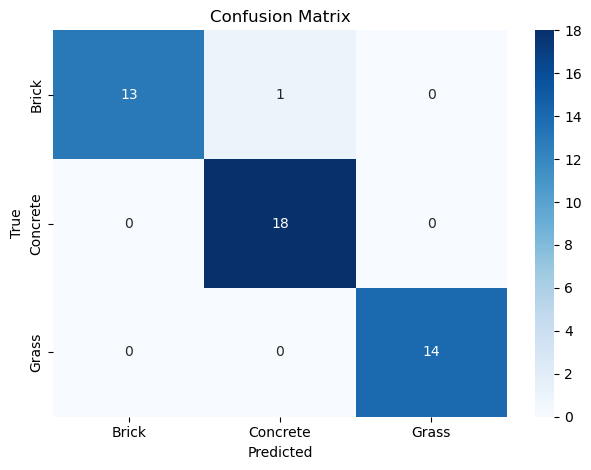

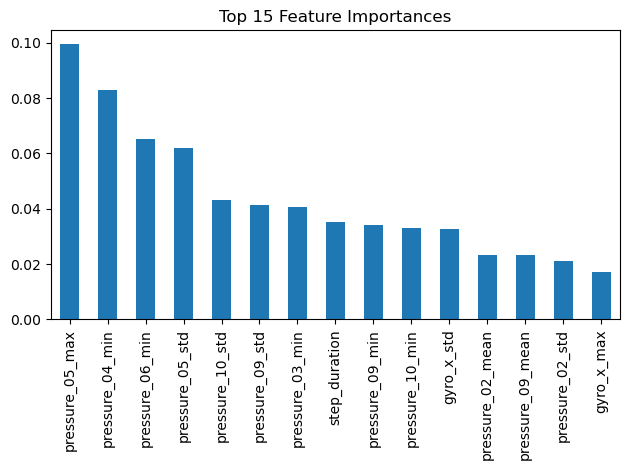

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X = X_reduced
y = steps_df['ground_type']

# ── 1. Split ──────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
print(f"Test class distribution:\n{y_test.value_counts()}")

# ── 2. Train ──────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# ── 3. Evaluate ───────────────────────────────────────────────────
y_pred = rf.predict(X_test)
print(f"\nTest Accuracy: {rf.score(X_test, y_test):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ── 4. Confusion matrix ───────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# ── 5. Feature importances ────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='bar')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [16]:
print(steps_df.columns)

Index(['ground_type', 'step', 'step_duration', 'total_pressure_mean',
       'stance_auc', 'pressure_01_mean', 'pressure_01_std', 'pressure_01_max',
       'pressure_01_min', 'pressure_01_skew',
       ...
       'magn_z_max', 'magn_z_min', 'magn_z_skew', 'magn_z_kurtosis',
       'loading_rate', 'midstance_pressure', 'midstance_time_sec',
       'time_to_midstance', 'crossover_found', 'predicted_ground_type'],
      dtype='object', length=137)


In [ ]:
# Add model prediction for every step
steps_df['predicted_ground_type'] = rf.predict(X_reduced)

# Build a clean chronological timeline
timeline_df = steps_df[[
    'ground_type',
    'predicted_ground_type',
    'step',
    'contact_time_sec',
    'loading_rate',
    'midstance_pressure'
]].copy()

timeline_df = timeline_df.sort_values('contact_time_sec').reset_index(drop=True)

# Add walk progress %
timeline_df['walk_progress_pct'] = (
    (timeline_df.index + 1) / len(timeline_df) * 100
)

# Print the full timeline
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.width', None,
                       'display.max_colwidth', None):
    print(timeline_df.to_string(index=False))

# Save for reuse
timeline_df.to_csv("step_timeline_full.csv", index=False)
print("\nSaved: step_timeline_full.csv")


KeyError: "['time_elapsed'] not in index"

In [ ]:
from scipy.signal import find_peaks as _find_peaks
import numpy as np
import pandas as pd

# Make sure these are defined the same way as earlier in your notebook
# Example:
# HEEL_SENSORS = ['pressure_08', 'pressure_10', 'pressure_11']

def compute_contact_times(df, big_peaks):
    """
    For each detected step window:
      - finds heel-contact as the minimum of the combined heel signal
      - returns a dataframe with the step number and its contact time
    """
    heel_sig = df[HEEL_SENSORS].sum(axis=1).values.astype(float)
    t = df['time_sec'].values

    rows = []
    for i in range(len(big_peaks) - 1):
        p1, p2 = big_peaks[i], big_peaks[i + 1]

        c_local = int(np.argmin(heel_sig[p1:p2]))
        c_idx = p1 + c_local

        rows.append({
            'step': i + 1,
            'contact_time_sec': float(t[c_idx])
        })

    return pd.DataFrame(rows)


# Build contact-time table for each surface
contact_dfs = []
for label, df in surfaces.items():
    big_peaks = find_step_windows(df)
    contact_df = compute_contact_times(df, big_peaks)
    contact_df['ground_type'] = label
    contact_dfs.append(contact_df)

contact_all = pd.concat(contact_dfs, ignore_index=True)

# Merge into your main step table
steps_df = steps_df.merge(contact_all, on=['ground_type', 'step'], how='left')

print(steps_df[['ground_type', 'step', 'contact_time_sec']].head(10))
print("Contact times added:", steps_df['contact_time_sec'].notna().sum(), "/", len(steps_df))

  ground_type  step  contact_time_sec
0    Concrete     1             1.840
1    Concrete     2             2.976
2    Concrete     3             4.096
3    Concrete     4             5.184
4    Concrete     5             6.288
5    Concrete     6             7.456
6    Concrete     7             8.592
7    Concrete     8             9.744
8    Concrete     9            10.864
9    Concrete    10            12.016
Contact times added: 309 / 309


In [ ]:
# ── Print the full step table and save it for animation ─────────────────────
import pandas as pd
import numpy as np

# Predict ground condition for every step in chronological order
steps_df['predicted_ground_type'] = rf.predict(X_reduced)

# Optional: keep a clean timeline table for animation / display
timeline_df = steps_df[[
    'step',
    'ground_type',
    'predicted_ground_type',
    'contact_time_sec',
    'midstance_time_sec',
    'loading_rate',
    'midstance_pressure'
]].copy()

timeline_df = timeline_df.sort_values('contact_time_sec').reset_index(drop=True)

# Print the FULL dataframe in the notebook output
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.width', None,
                       'display.max_colwidth', None):
    print(timeline_df.to_string(index=False))

# Save as CSV for later animation use
timeline_df.to_csv('step_timeline_full.csv', index=False)

print("\nSaved: step_timeline_full.csv")

 step ground_type predicted_ground_type  contact_time_sec  midstance_time_sec  loading_rate  midstance_pressure
    1       Brick                 Brick             1.536               1.536   1484.375000              2136.0
    1       Grass                 Grass             1.808               1.808    937.500000              2406.0
    1    Concrete              Concrete             1.840               1.840   1088.541667              2261.0
    2       Brick                 Brick             2.608               2.608   1555.208333              2397.0
    2    Concrete              Concrete             2.976               2.976    602.272727              2181.0
    2       Grass                 Grass             2.992               2.992    993.750000              2226.0
    3       Brick                 Brick             3.728               3.728   1212.797619              2231.0
    3    Concrete              Concrete             4.096               4.096   1299.851190             

In [ ]:
with pd.option_context('display.max_rows', None,
                       'display.max_columns', None,
                       'display.width', None,
                       'display.max_colwidth', None):
    print(steps_df.to_string(index=False))

ground_type  step  step_duration  total_pressure_mean  stance_auc  pressure_01_mean  pressure_01_std  pressure_01_max  pressure_01_min  pressure_01_skew  pressure_01_kurtosis  pressure_02_mean  pressure_02_std  pressure_02_max  pressure_02_min  pressure_02_skew  pressure_02_kurtosis  pressure_03_mean  pressure_03_std  pressure_03_max  pressure_03_min  pressure_03_skew  pressure_03_kurtosis  pressure_04_mean  pressure_04_std  pressure_04_max  pressure_04_min  pressure_04_skew  pressure_04_kurtosis  pressure_05_mean  pressure_05_std  pressure_05_max  pressure_05_min  pressure_05_skew  pressure_05_kurtosis  pressure_06_mean  pressure_06_std  pressure_06_max  pressure_06_min  pressure_06_skew  pressure_06_kurtosis  pressure_07_mean  pressure_07_std  pressure_07_max  pressure_07_min  pressure_07_skew  pressure_07_kurtosis  pressure_08_mean  pressure_08_std  pressure_08_max  pressure_08_min  pressure_08_skew  pressure_08_kurtosis  pressure_09_mean  pressure_09_std  pressure_09_max  pressure_

In [ ]:
# Make sure timeline_df is sorted in walking order
timeline_df = timeline_df.sort_values('contact_time_sec').reset_index(drop=True)

# Add progress column
timeline_df['walk_progress_pct'] = (
    (timeline_df.index + 1) / len(timeline_df) * 100
)

# Check it worked
print(timeline_df[['contact_time_sec', 'walk_progress_pct']].head())

   contact_time_sec  walk_progress_pct
0             1.536           0.323625
1             1.808           0.647249
2             1.840           0.970874
3             2.608           1.294498
4             2.976           1.618123


In [ ]:
import plotly.graph_objects as go

n_steps = len(timeline_df)

frames = []
for i in range(n_steps):
    current = timeline_df.iloc[i]
    progress = current['walk_progress_pct']

    # show last few steps as history
    history_start = max(0, i - 4)
    recent = timeline_df.iloc[history_start:i+1].copy()

    recent_text = "<br>".join(
        [
            f"Step {idx+1}: true={row['ground_type']} | pred={row['predicted_ground_type']}"
            for idx, row in recent.iterrows()
        ]
    )

    frame = go.Frame(
        name=str(i),
        data=[
            # progress bar
            go.Bar(
                x=[progress],
                y=["Walk Progress"],
                orientation="h",
                width=[0.45],
                text=[f"{progress:.1f}%"],
                textposition="inside"
            )
        ],
        layout=go.Layout(
            annotations=[
                dict(
                    x=0.5, y=0.95, xref="paper", yref="paper",
                    text=f"<b>Step {i+1} of {n_steps}</b>",
                    showarrow=False,
                    font=dict(size=22)
                ),
                dict(
                    x=0.5, y=0.78, xref="paper", yref="paper",
                    text=f"Predicted ground: <b>{current['predicted_ground_type']}</b>",
                    showarrow=False,
                    font=dict(size=20)
                ),
                dict(
                    x=0.5, y=0.68, xref="paper", yref="paper",
                    text=f"True ground: <b>{current['ground_type']}</b>",
                    showarrow=False,
                    font=dict(size=18)
                ),
                dict(
                    x=0.5, y=0.58, xref="paper", yref="paper",
                    text=f"Contact time: {current['contact_time_sec']:.2f} s",
                    showarrow=False,
                    font=dict(size=16)
                ),
                dict(
                    x=0.5, y=0.48, xref="paper", yref="paper",
                    text=f"Loading rate: {current['loading_rate']:.1f}" if pd.notna(current['loading_rate']) else "Loading rate: NA",
                    showarrow=False,
                    font=dict(size=16)
                ),
                dict(
                    x=0.5, y=0.18, xref="paper", yref="paper",
                    text=f"Recent steps:<br>{recent_text}",
                    showarrow=False,
                    align="left",
                    font=dict(size=14)
                )
            ]
        )
    )
    frames.append(frame)

# Initial frame
first = timeline_df.iloc[0]

fig = go.Figure(
    data=[
        go.Bar(
            x=[first['walk_progress_pct']],
            y=["Walk Progress"],
            orientation="h",
            width=[0.45],
            text=[f"{first['walk_progress_pct']:.1f}%"],
            textposition="inside"
        )
    ],
    layout=go.Layout(
        title="Walk Progress and Ground Condition by Step",
        xaxis=dict(range=[0, 100], title="Percent of walk completed"),
        yaxis=dict(showticklabels=True),
        template="plotly_white",
        height=700,
        updatemenus=[
            {
                "type": "buttons",
                "showactive": False,
                "buttons": [
                    {
                        "label": "Play",
                        "method": "animate",
                        "args": [None, {
                            "frame": {"duration": 500, "redraw": True},
                            "transition": {"duration": 200},
                            "fromcurrent": True
                        }]
                    },
                    {
                        "label": "Pause",
                        "method": "animate",
                        "args": [[None], {
                            "frame": {"duration": 0, "redraw": False},
                            "mode": "immediate",
                            "transition": {"duration": 0}
                        }]
                    }
                ]
            }
        ],
        annotations=[
            dict(
                x=0.5, y=0.95, xref="paper", yref="paper",
                text=f"<b>Step 1 of {n_steps}</b>",
                showarrow=False,
                font=dict(size=22)
            ),
            dict(
                x=0.5, y=0.78, xref="paper", yref="paper",
                text=f"Predicted ground: <b>{first['predicted_ground_type']}</b>",
                showarrow=False,
                font=dict(size=20)
            ),
            dict(
                x=0.5, y=0.68, xref="paper", yref="paper",
                text=f"True ground: <b>{first['ground_type']}</b>",
                showarrow=False,
                font=dict(size=18)
            ),
            dict(
                x=0.5, y=0.58, xref="paper", yref="paper",
                text=f"Contact time: {first['contact_time_sec']:.2f} s",
                showarrow=False,
                font=dict(size=16)
            ),
            dict(
                x=0.5, y=0.48, xref="paper", yref="paper",
                text=f"Loading rate: {first['loading_rate']:.1f}" if pd.notna(first['loading_rate']) else "Loading rate: NA",
                showarrow=False,
                font=dict(size=16)
            )
        ]
    ),
    frames=frames
)

fig.show()